In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv(
    "../Data/household_power_consumption.txt",
    sep=";"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [20]:
print("Shape:", df.shape)

df.info()

Shape: (2075259, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [21]:
df['day'] = df['Date'].apply(lambda x: x.split('/')[0])
df['month'] = df['Date'].apply(lambda x: x.split('/')[1])
df['year'] = df['Date'].apply(lambda x: x.split('/')[2])

df['min'] = df['Time'].apply(lambda x:x.split(':')[1])
df['hour'] = df['Time'].apply(lambda x:x.split(':')[0])

In [22]:
# df.drop(columns=['Date', 'Time'], inplace=True)

In [23]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day,month,year,min,hour
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,16,12,2006,24,17
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,16,12,2006,25,17
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,16,12,2006,26,17
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,16,12,2006,27,17
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,16,12,2006,28,17


In [24]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
day                          0
month                        0
year                         0
min                          0
hour                         0
dtype: int64

In [25]:
df['Sub_metering_3'].fillna(df['Sub_metering_3'].mean(), inplace=True)

In [26]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
day                      0
month                    0
year                     0
min                      0
hour                     0
dtype: int64

In [27]:
df.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
day                      0
month                    0
year                     0
min                      0
hour                     0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
 9   day                    object 
 10  month                  object 
 11  year                   object 
 12  min                    object 
 13  hour                   object 
dtypes: float64(1), object(13)
memory usage: 221.7+ MB


In [29]:
df['Global_active_power'].replace('?', 0, inplace=True)
df['Voltage'].replace('?', 0, inplace=True)
df['Global_reactive_power'].replace('?', 0, inplace=True)
# df['Global_intensity'].replace('?', 0, inplace=True)
df['Sub_metering_1'].replace('?', 0, inplace=True)
df['Sub_metering_2'].replace('?', 0, inplace=True)
df['Sub_metering_3'].replace('?', 0, inplace=True)
df['Global_intensity'].replace('?', 0, inplace=True)
df['Global_active_power'] = df['Global_active_power'].astype(float)
df['Global_reactive_power'] = df['Global_reactive_power'].astype(float)
df['Voltage'] = df['Voltage'].astype(float)
# df['Global_intensity'] = df['Global_intensity'].astype(float)
df['Sub_metering_1'] = df['Sub_metering_1'].astype(float)
df['Sub_metering_2'] = df['Sub_metering_2'].astype(float)
df['Sub_metering_3'] = df['Sub_metering_3'].astype(float)
df['day'] = df['day'].astype(float)
df['month'] = df['month'].astype(float)
df['min'] = df['min'].astype(float)
df['year'] = df['year'].astype(float)
df['hour'] = df['hour'].astype(float)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       object 
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   day                    float64
 10  month                  float64
 11  year                   float64
 12  min                    float64
 13  hour                   float64
dtypes: float64(11), object(3)
memory usage: 221.7+ MB


In [31]:
df.drop('Date', inplace=True, axis=1)
df.drop('Time', inplace=True, axis=1)
df.drop('Global_intensity', inplace=True, axis=1)

In [32]:
df.astype(float)

,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,day,month,year,min,hour
0,4.216,0.418,234.84,0.0,1.0,17.0,16.0,12.0,2006.0,24.0,17.0
1,5.360,0.436,233.63,0.0,1.0,16.0,16.0,12.0,2006.0,25.0,17.0
2,5.374,0.498,233.29,0.0,2.0,17.0,16.0,12.0,2006.0,26.0,17.0
3,5.388,0.502,233.74,0.0,1.0,17.0,16.0,12.0,2006.0,27.0,17.0
4,3.666,0.528,235.68,0.0,1.0,17.0,16.0,12.0,2006.0,28.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
2075254,0.946,0.000,240.43,0.0,0.0,0.0,26.0,11.0,2010.0,58.0,20.0
2075255,0.944,0.000,240.00,0.0,0.0,0.0,26.0,11.0,2010.0,59.0,20.0
2075256,0.938,0.000,239.82,0.0,0.0,0.0,26.0,11.0,2010.0,0.0,21.0
2075257,0.934,0.000,239.70,0.0,0.0,0.0,26.0,11.0,2010.0,1.0,21.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Sub_metering_1         float64
 4   Sub_metering_2         float64
 5   Sub_metering_3         float64
 6   day                    float64
 7   month                  float64
 8   year                   float64
 9   min                    float64
 10  hour                   float64
dtypes: float64(11)
memory usage: 174.2 MB


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
print(df.isna().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
day                      0
month                    0
year                     0
min                      0
hour                     0
dtype: int64


# EDA

### Missing values

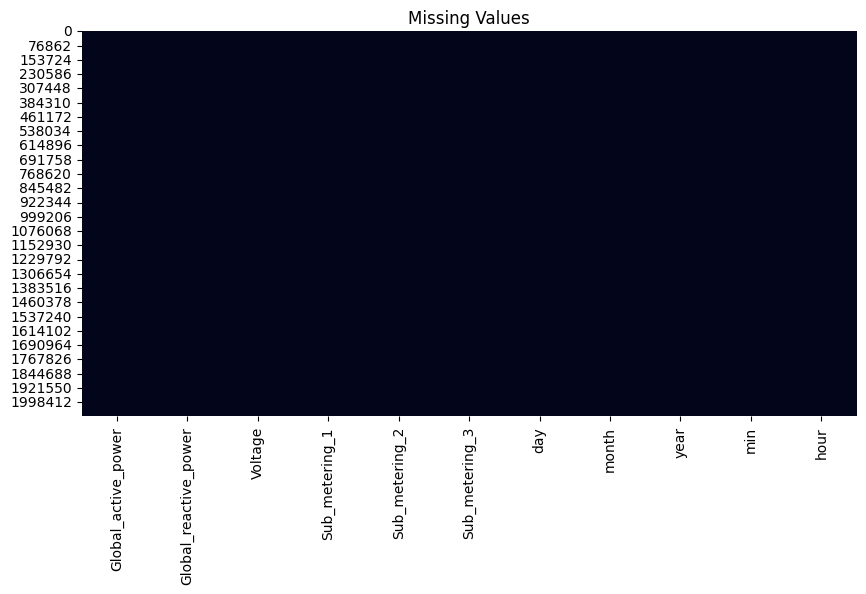

In [39]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df.isnull(),
    cbar=False
)
plt.title("Missing Values")
plt.show()

### Target distribution

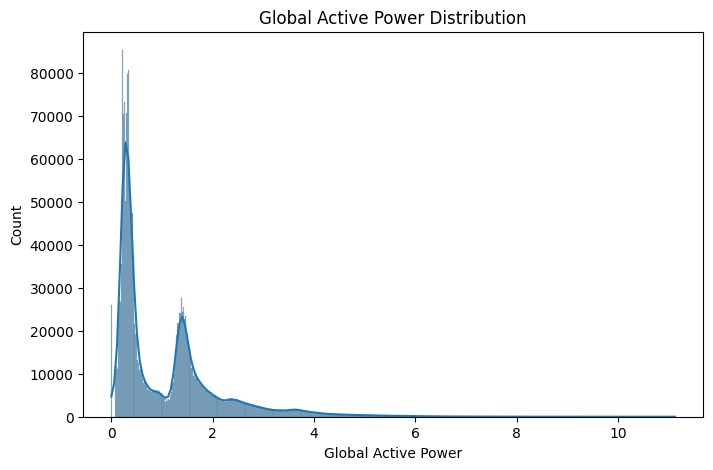

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Global_active_power"],
    kde=True
)

plt.title("Global Active Power Distribution")
plt.xlabel("Global Active Power")
plt.show()

### Correlation

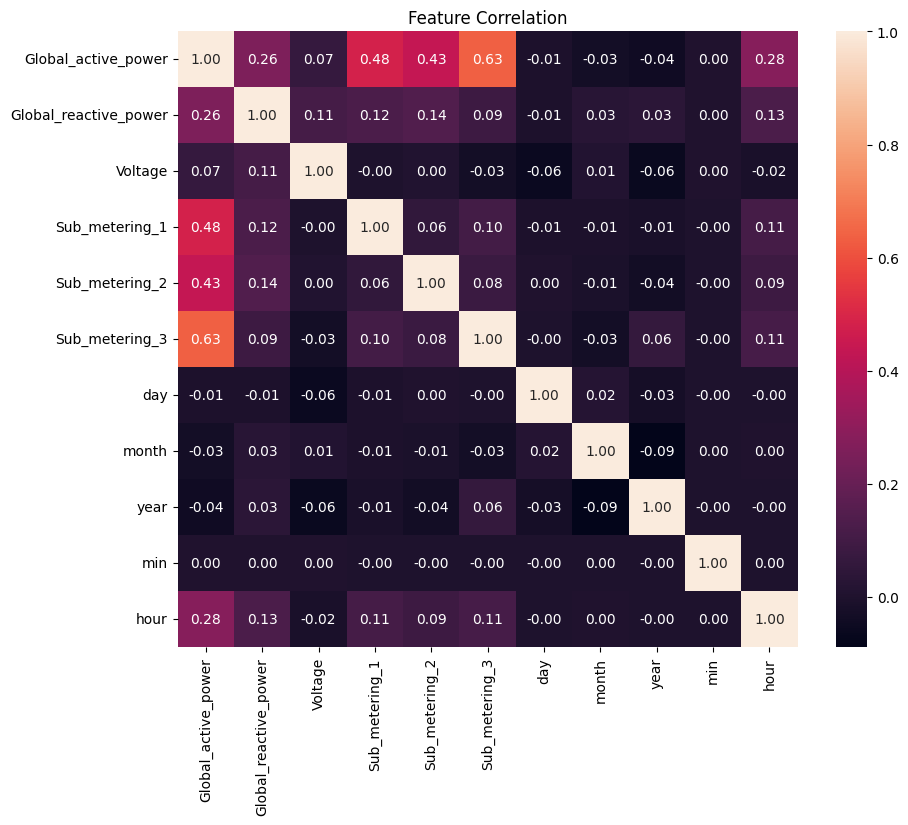

In [90]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.savefig(
    "../outputs/figures/correlation_heatmap.png",
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

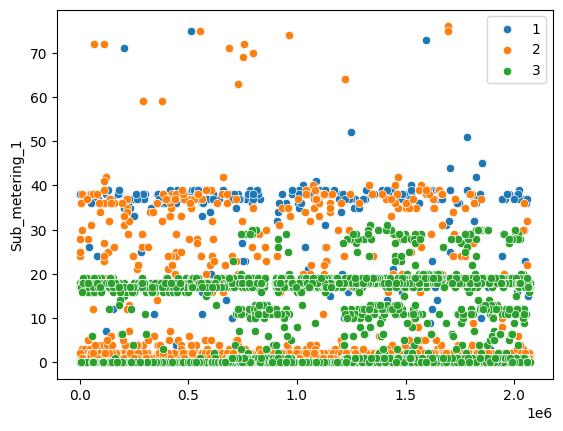

In [45]:
sns.scatterplot(data=df['Sub_metering_1'].sample(10000), label='1')
sns.scatterplot(data=df['Sub_metering_2'].sample(10000), label='2')
sns.scatterplot(data=df['Sub_metering_3'].sample(10000), label='3')
plt.legend()

In [46]:
X = df.drop(columns=['Global_active_power'])
y = df['Global_active_power']

In [47]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2075259, 10)
y shape: (2075259,)


In [48]:
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split

### Train/test split

In [49]:
X_train , X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1660207, 10), (415052, 10), (1660207,), (415052,))

In [54]:
X_test.fillna(X_test.mean(), inplace=True)
y_test.fillna(y_test.mean(), inplace=True)


## Scaling

In [62]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

# XGBoost comparison

In [55]:
import xgboost as xgb

In [57]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train_scale,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [63]:
xgb_pred = xgb_model.predict(X_test_scale)

In [64]:
y_test.shape

(415052,)

In [65]:
xgb_pred.shape

(415052,)

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 0.2287930889364463
XGBoost RMSE: 0.38100897463045247
XGBoost R2: 0.8703044205123497


In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_model = Sequential([
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scale.shape[1],)
    ),

    Dense(64, activation="relu"),

    Dense(32, activation="relu"),

    Dense(16, activation="relu"),

    Dense(8, activation="relu"),

    Dense(1, activation="linear")
])

In [69]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
ann_model.compile(optimizer='Adam',loss="mse")

In [73]:
history = ann_model.fit(
    X_train_scale,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 0.1720 - val_loss: 0.1523
Epoch 2/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 0.1507 - val_loss: 0.1484
Epoch 3/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 0.1441 - val_loss: 0.1407
Epoch 4/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - loss: 0.1398 - val_loss: 0.1397
Epoch 5/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 0.1361 - val_loss: 0.1336
Epoch 6/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - loss: 0.1331 - val_loss: 0.1323
Epoch 7/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 0.1307 - val_loss: 0.1294
Epoch 8/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 0.1286 - val_loss: 0.1317
Epoch 9/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 0.1268 - val_loss: 0.1270
Epoch 10/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 0.1250 - val_loss: 0.1244
Epoch 11/30
20753/20753 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 0.1235 - val_loss: 0.12

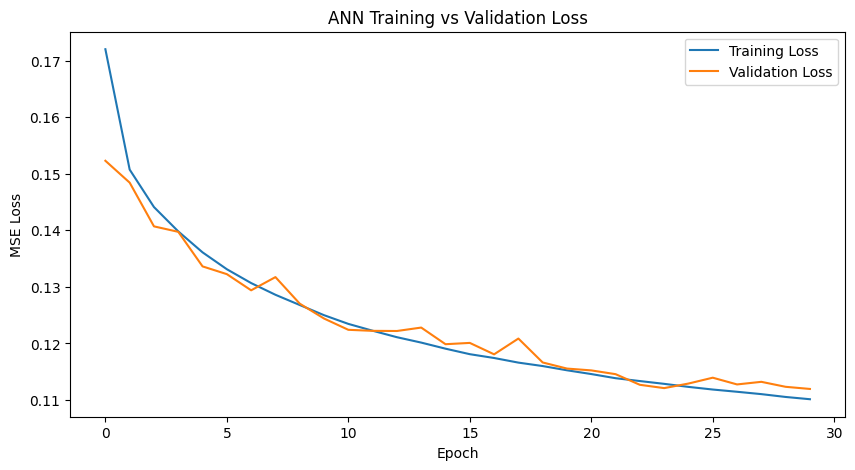

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ANN Training vs Validation Loss")
plt.savefig(
    "../outputs/figures/training_loss.png",
    bbox_inches="tight"
)
plt.legend()
plt.show()

In [76]:
plt.savefig(
    "../outputs/figures/training_loss.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [78]:
y_pred_ann = ann_model.predict(
    X_test_scale
).flatten()

12971/12971 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step


In [80]:
print("NaN:", np.isnan(y_pred_ann).sum())
print("Inf:", np.isinf(y_pred_ann).sum())

NaN: 0
Inf: 0


# ANN evaluation

In [81]:
ann_mae = mean_absolute_error(y_test, y_pred_ann)
ann_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ann))
ann_r2 = r2_score(y_test,y_pred_ann)

print("ANN MAE:", ann_mae)
print("ANN RMSE:", ann_rmse)
print("ANN R2:", ann_r2)

ANN MAE: 0.20653268448893108
ANN RMSE: 0.3353853446982646
ANN R2: 0.8995053538033347


In [82]:
results = pd.DataFrame({
    "Model": ["XGBoost", "ANN"],
    "MAE": [xgb_mae, ann_mae],
    "RMSE": [xgb_rmse, ann_rmse],
    "R2": [xgb_r2, ann_r2]
})

results

,Model,MAE,RMSE,R2
0,XGBoost,0.228793,0.381009,0.870304
1,ANN,0.206533,0.335385,0.899505


In [84]:
results.to_csv(
    "../outputs/results/model_results.csv",
    index=False
)

## Save ANN model

In [85]:
ann_model.save(
    "../models/ann_model.keras"
)

## Save scaler

In [86]:
import joblib

joblib.dump(scaler,"../models/scaler.pkl")

['../models/scaler.pkl']

## Save feature names

In [87]:
feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/feature_ columns.pkl"
)

print(feature_columns)

['Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day', 'month', 'year', 'min', 'hour']
